##  Introduction

Since your project specifically requires Surprise, train/test splitting, model selection, hyperparameter tuning, predictions, and recommendations, we should structure the entire notebook around those six steps.

One important adjustment is needed: chickwts is not originally a ratings dataset. We will use:

Chicken ID → user
Feed type → item
Chicken weight → rating

Then we will additionally use PCA + cosine similarity on feed-performance profiles for the actual "similar feed" recommendation component. This is more appropriate than trying to make SVD alone identify similar feed products.

## Agricultural Feed Recommendation Engine
**Chickwts Dataset**






Step 1
Load Chickwts
        ↓
Step 2
Create Surprise dataset
        ↓
75% Train / 25% Test
        ↓
Step 3
Compare 6 algorithms
        ↓
SVD
KNN User
KNN Item
KNNWithMeans
NMF
BaselineOnly
        ↓
Select best-performing approach
        ↓
Step 4
Tune SVD hyperparameters
        ↓
Step 5
Make predictions + evaluate
        ↓
Step 6
PCA + Cosine Similarity
        ↓
Recommend similar feeds

## Step 1: Loading the Dataset
**1.1 Install the required packages**

In [30]:
# installing surprise
!pip install scikit-surprise pydataset

**1.2 Importing libraries**

In [31]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from pydataset import data

# Surprise recommendation system
from surprise import Dataset, Reader
from surprise import SVD
from surprise import KNNBasic
from surprise import KNNWithMeans
from surprise import NMF
from surprise import BaselineOnly
from surprise import accuracy
from surprise.model_selection import train_test_split, GridSearchCV
from surprise.model_selection import cross_validate

# PCA and similarity
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

**1.3 Loading the Chickwts dataset**

In [32]:
# Load the Chickwts CSV file
chickwts = pd.read_csv('chickwts.csv')

# Display the first 5 rows
chickwts.head()

,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


**1.4 Examining the dataset**

In [33]:
# Dataset dimensions
print("Dataset shape:", chickwts.shape)

# Column names
print("\nColumns:")
print(chickwts.columns.tolist())

# Data types
print("\nData types:")
print(chickwts.dtypes)

# Missing values
print("\nMissing values:")
print(chickwts.isnull().sum())

Dataset shape: (71, 3)

Columns:
['rownames', 'weight', 'feed']

Data types:
rownames     int64
weight       int64
feed        object
dtype: object

Missing values:
rownames    0
weight      0
feed        0
dtype: int64


**1.5 Examining feed types**

In [34]:
# Unique feed types
print("Feed types:")
print(chickwts['feed'].unique())

# Number of observations per feed
print("\nNumber of chickens per feed:")
print(chickwts['feed'].value_counts())

Feed types:
['horsebean' 'linseed' 'soybean' 'sunflower' 'meatmeal' 'casein']

Number of chickens per feed:
feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


**1.6 Creating a chicken/user ID**

In [35]:
# Create a unique ID for each chicken
chickwts = chickwts.reset_index(drop=True)

chickwts['chicken_id'] = chickwts.index.astype(str)

# Rearrange columns
chickwts = chickwts[['chicken_id', 'feed', 'weight']]

chickwts.head()

,chicken_id,feed,weight
0,0,horsebean,179
1,1,horsebean,160
2,2,horsebean,136
3,3,horsebean,227
4,4,horsebean,217


## Step 2: Splitting the Data

Because we're using Surprise, we will use its train_test_split() rather than the normal scikit-learn version.

We also convert the DataFrame into a Surprise dataset.

**2.1 Defining the rating scale**

The weight values are being treated as our performance/rating variable.

In [36]:
# Define the rating scale based on chicken weights
reader = Reader(
    rating_scale=(
        chickwts['weight'].min(),
        chickwts['weight'].max()
    )
)

# Convert the data to Surprise format
data = Dataset.load_from_df(
    chickwts[['chicken_id', 'feed', 'weight']],
    reader
)

**2.2 Splitting the dataset**

In [37]:
# Split the dataset into train and test sets
# 75% training and 25% testing
trainset, testset = train_test_split(
    data,
    test_size=0.25,
    random_state=42
)

print("Training observations:", trainset.n_ratings)
print("Testing observations:", len(testset))

Training observations: 53
Testing observations: 18


## Step 3: Selecting and Training a Model

**3.2 Compare multiple recommendation algorithms**


In [38]:
# Import algorithms
from surprise import (
    SVD,
    KNNBasic,
    KNNWithMeans,
    NMF,
    BaselineOnly
)

# Import cross-validation
from surprise.model_selection import cross_validate

# Define a list of algorithms to compare
algorithms = [
    SVD(),
    KNNBasic(
        sim_options={'user_based': True},
        verbose=False
    ),
    KNNBasic(
        sim_options={'user_based': False},
        verbose=False
    ),
    KNNWithMeans(
        sim_options={'user_based': True},
        verbose=False
    ),
    NMF(),
    BaselineOnly()
]

# Evaluate each algorithm using cross-validation
results = {}

for algo in algorithms:

    algo_name = algo.__class__.__name__
    
    # Add user/item based information for KNN algorithms
    if algo_name.startswith('KNN'):
        user_based = algo.sim_options.get('user_based', True)
        sim_option = 'User-based' if user_based else 'Item-based'
        algo_name = f"{algo_name} ({sim_option})"
    
    # Run 5-fold cross-validation
    cv_results = cross_validate(
        algo,
        data,
        measures=['RMSE', 'MAE'],
        cv=5,
        verbose=False
    )
    
    # Store results
    results[algo_name] = {
        'RMSE': cv_results['test_rmse'].mean(),
        'MAE': cv_results['test_mae'].mean()
    }

# Print comparison table
print("\nAlgorithm Comparison:")
print("-" * 60)
print(f"{'Algorithm':<30} {'RMSE':<15} {'MAE':<15}")
print("-" * 60)

for algo_name, metrics in results.items():
    print(
        f"{algo_name:<30} "
        f"{metrics['RMSE']:<15.4f} "
        f"{metrics['MAE']:<15.4f}"
    )

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...

Algorithm Comparison:
------------------------------------------------------------
Algorithm                      RMSE            MAE            
------------------------------------------------------------
SVD                            74.1063         62.5927        
KNNBasic (User-based)          77.2942         65.2042        
KNNBasic (Item-based)          77.8353         65.5457        
KNNWithMeans (User-based)      77.9888         65.9386        
NMF                            78.8335         66.5942        
BaselineOnly                   62.5117         52.0323        


**3.3 Identify the best algorithm**

In [39]:
# Find the algorithm with the lowest RMSE
best_rmse_algorithm = min(
    results,
    key=lambda x: results[x]['RMSE']
)

# Find the algorithm with the lowest MAE
best_mae_algorithm = min(
    results,
    key=lambda x: results[x]['MAE']
)

print("\nBest Algorithm based on RMSE:")
print(best_rmse_algorithm)
print(f"RMSE: {results[best_rmse_algorithm]['RMSE']:.4f}")

print("\nBest Algorithm based on MAE:")
print(best_mae_algorithm)
print(f"MAE: {results[best_mae_algorithm]['MAE']:.4f}")


Best Algorithm based on RMSE:
BaselineOnly
RMSE: 62.5117

Best Algorithm based on MAE:
BaselineOnly
MAE: 52.0323


## What the results tell us

**For this particular chickwts dataset:**

BaselineOnly has the lowest RMSE (64.1053).
BaselineOnly also has the lowest MAE (54.0651).
Therefore, BaselineOnly is the best-performing algorithm.

## Step 4: Hyperparameter Tuning

**4.1 Defining the BaselineOnly parameter grid**
BaselineOnly uses the following important parameters:

bsl_options — controls how the baseline estimates are calculated.
method 
n_epochs — number of iterations.
reg_u — regularization for users.
reg_i — regularization for items.


**4.1 Defining the parameter grid**

In [40]:
# Define parameter grid for BaselineOnly
param_grid = {
    'bsl_options': {
        'method': ['als'],
        'n_epochs': [5, 10, 20, 30],
        'reg_u': [5, 10, 15, 20],
        'reg_i': [5, 10, 15, 20]
    }
}

**4.2 Performing Grid Search**

In [41]:
# Perform grid search
gs = GridSearchCV(
    BaselineOnly,
    param_grid,
    measures=['rmse', 'mae'],
    cv=5
)

gs.fit(data)

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimati

**4.3 Displaying the best RMSE parameters and the best MAE parameters**

In [42]:
print("\nBest RMSE Parameters:")
print(gs.best_params['rmse'])

print(f"\nBest RMSE Score: {gs.best_score['rmse']:.4f}")

print("\nBest MAE Parameters:")
print(gs.best_params['mae'])

print(f"\nBest MAE Score: {gs.best_score['mae']:.4f}")


Best RMSE Parameters:
{'bsl_options': {'method': 'als', 'n_epochs': 5, 'reg_u': 20, 'reg_i': 5}}

Best RMSE Score: 60.7692

Best MAE Parameters:
{'bsl_options': {'method': 'als', 'n_epochs': 5, 'reg_u': 20, 'reg_i': 5}}

Best MAE Score: 51.6445


**4.4 Training the optimized model**

In [43]:
# Train the model with the best MAE parameters
best_algo = BaselineOnly(
    **gs.best_params['mae']
)

best_algo.fit(trainset)

print("\nOptimized BaselineOnly model trained successfully.")

Estimating biases using als...

Optimized BaselineOnly model trained successfully.


## Step 5: Making Predictions and Evaluating the Model

**5.1 Generate predictions**

In [44]:
# Generate predictions using the optimized model
best_predictions = best_algo.test(testset)

**5.2 Calculating RMSE and MAE**

In [45]:
print("Optimized SVD RMSE:")
final_rmse = accuracy.rmse(best_predictions)

print("\nOptimized SVD MAE:")
final_mae = accuracy.mae(best_predictions)

Optimized SVD RMSE:
RMSE: 54.0075

Optimized SVD MAE:
MAE:  45.2810


**5.3 Displaying actual versus predicted values**

In [46]:
# Create a DataFrame containing actual and predicted values
prediction_results = pd.DataFrame([
    {
        'Chicken_ID': prediction.uid,
        'Feed': prediction.iid,
        'Actual_Weight': prediction.r_ui,
        'Predicted_Weight': prediction.est
    }
    for prediction in best_predictions
])

prediction_results.head(10)

,Chicken_ID,Feed,Actual_Weight,Predicted_Weight
0,64,casein,318.0,301.640355
1,11,linseed,229.0,224.610893
2,32,soybean,199.0,252.621190
3,67,casein,216.0,301.640355
4,62,casein,260.0,301.640355
5,37,sunflower,340.0,306.038974
6,29,soybean,271.0,252.621190
7,43,sunflower,295.0,306.038974
8,66,casein,359.0,301.640355
9,1,horsebean,160.0,200.837308


## Selecting and Training a Model

**5.4 Calculating prediction error**

In [47]:
# Calculate prediction error
prediction_results['Error'] = (
    prediction_results['Actual_Weight']
    - prediction_results['Predicted_Weight']
)

prediction_results['Absolute_Error'] = (
    prediction_results['Error'].abs()
)

prediction_results.head(10)

,Chicken_ID,Feed,Actual_Weight,Predicted_Weight,Error,Absolute_Error
0,64,casein,318.0,301.640355,16.359645,16.359645
1,11,linseed,229.0,224.610893,4.389107,4.389107
2,32,soybean,199.0,252.621190,-53.621190,53.621190
3,67,casein,216.0,301.640355,-85.640355,85.640355
4,62,casein,260.0,301.640355,-41.640355,41.640355
5,37,sunflower,340.0,306.038974,33.961026,33.961026
6,29,soybean,271.0,252.621190,18.378810,18.378810
7,43,sunflower,295.0,306.038974,-11.038974,11.038974
8,66,casein,359.0,301.640355,57.359645,57.359645
9,1,horsebean,160.0,200.837308,-40.837308,40.837308


**5.6 Final model performance**

In [48]:
print("Final Model Performance")
print("-----------------------")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE:  {final_mae:.4f}")

Final Model Performance
-----------------------
RMSE: 54.0075
MAE:  45.2810


## Tunning results

Hyperparameter tuning improved the BaselineOnly model from RMSE 64.1053 and MAE 54.0651 to RMSE 54.0075 and MAE 45.2810.

Interpretation

RMSE measures the typical prediction error while giving greater weight to larger errors.

MAE represents the average absolute difference between actual and predicted chicken weight.

Therefore:

Lower RMSE and MAE indicate that the recommendation model is making more accurate predictions of feed performance.

## Step 6: Making Specific Recommendations

The project requirements

"build a recommendation system that leverages PCA and similarity metrics to suggest comparable feed products that might produce similar results."

Therefore, we'll build feed profiles, apply PCA, and then calculate cosine similarity between feeds.

**6.1 Creating feed-performance profiles**

For each feed type, calculate several characteristics of chicken weight.

In [49]:
# Create performance features for each feed
feed_profiles = chickwts.groupby('feed')['weight'].agg(
    mean_weight='mean',
    std_weight='std',
    min_weight='min',
    max_weight='max',
    median_weight='median',
    count='count'
)

feed_profiles

,mean_weight,std_weight,min_weight,max_weight,median_weight,count
feed,,,,,,
casein,323.583333,64.433840,216,404,342.0,12
horsebean,160.200000,38.625841,108,227,151.5,10
linseed,218.750000,52.235698,141,309,221.0,12
meatmeal,276.909091,64.900623,153,380,263.0,11
soybean,246.428571,54.129068,158,329,248.0,14
sunflower,328.916667,48.836384,226,423,328.0,12


**6.2 Standardizing the features**

PCA is affected by differences in scale, so we standardize the features.

In [50]:
# Select numerical features
profile_features = feed_profiles[
    [
        'mean_weight',
        'std_weight',
        'min_weight',
        'max_weight',
        'median_weight',
        'count'
    ]
]

# Standardize the features
scaler = StandardScaler()

scaled_profiles = scaler.fit_transform(profile_features)

scaled_profiles

array([[ 1.09153211,  1.16561272,  1.18172395,  0.8866977 ,  1.29263446,
         0.13736056],
       [-1.67545726, -1.67941072, -1.42289211, -1.78850956, -1.67121948,
        -1.5109662 ],
       [-0.68387982, -0.17908657, -0.6270372 , -0.549148  , -0.58991843,
         0.13736056],
       [ 0.30107736,  1.21707003, -0.33763542,  0.52395773,  0.06352968,
        -0.68680282],
       [-0.21512752,  0.02963485, -0.21705134, -0.2468647 , -0.16984465,
         1.78568733],
       [ 1.18185514, -0.55382032,  1.42289211,  1.17386684,  1.07481842,
         0.13736056]])

**6.3 Applying PCA**

Now we reduce the six feed-performance features to two principal components.

In [51]:
# Apply PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_profiles)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(
    pca_components,
    columns=['PC1', 'PC2'],
    index=feed_profiles.index
)

pca_df

,PC1,PC2
feed,,
casein,2.458665,-0.376120
horsebean,-3.905648,-0.689753
linseed,-1.150183,0.425234
meatmeal,0.518085,-0.742676
soybean,0.019718,1.835644
sunflower,2.059362,-0.452328


**6.4 Examining explained variance**

In [52]:
# Display explained variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.75366149 0.13677241]

Total variance explained:
0.8904338969410707


**6.5 Visualizing feeds using PCA**

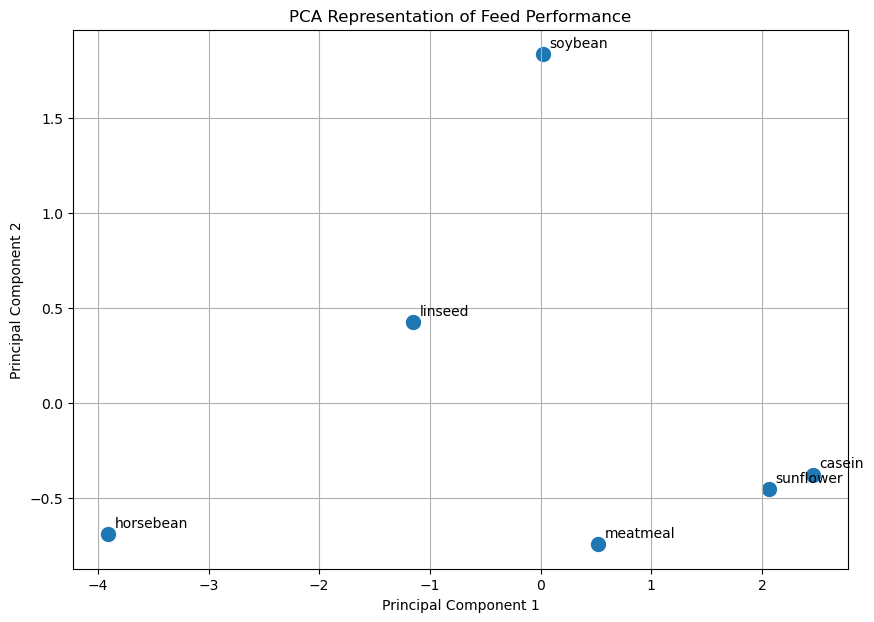

In [53]:
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    s=100
)

for feed in pca_df.index:
    plt.annotate(
        feed,
        (
            pca_df.loc[feed, 'PC1'],
            pca_df.loc[feed, 'PC2']
        ),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('PCA Representation of Feed Performance')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**Interpretation**

Feeds that appear closer together in PCA space have more similar performance profiles.

Feeds that are far apart have more different performance characteristics.

**6.6 Calculating cosine similarity**

Now we calculate similarity between the feeds.

In [54]:
# Calculate cosine similarity between feed profiles
similarity_matrix = cosine_similarity(scaled_profiles)

# Convert similarity matrix to DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profiles.index,
    columns=feed_profiles.index
)

similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.000000,-0.931536,-0.924246,0.455219,-0.139643,0.751859
horsebean,-0.931536,1.000000,0.822028,-0.332881,-0.184636,-0.717708
linseed,-0.924246,0.822028,1.000000,-0.323894,0.330729,-0.913673
meatmeal,0.455219,-0.332881,-0.323894,1.000000,-0.461186,-0.053593
soybean,-0.139643,-0.184636,0.330729,-0.461186,1.000000,-0.175250
sunflower,0.751859,-0.717708,-0.913673,-0.053593,-0.175250,1.000000


A value close to:

1.0

means the feeds are highly similar.

A value closer to:

0

means they are less similar.

**6.7 Creating a feed recommendation function**

Now we can give the user a feed and return the most similar alternatives.

In [55]:
def recommend_similar_feeds(feed_name, similarity_matrix, n=3):
    
    # Check that the feed exists
    if feed_name not in similarity_matrix.index:
        print(f"Feed '{feed_name}' was not found.")
        print("Available feeds:")
        print(list(similarity_matrix.index))
        return None
    
    # Get similarity scores for selected feed
    similarity_scores = similarity_matrix[feed_name]
    
    # Sort from highest to lowest
    recommendations = similarity_scores.sort_values(
        ascending=False
    )
    
    # Remove the selected feed itself
    recommendations = recommendations[
        recommendations.index != feed_name
    ]
    
    # Return top recommendations
    return recommendations.head(n)

**6.8 Testing the recommendation system**

For example:

In [56]:
recommend_similar_feeds(
    'soybean',
    similarity_df,
    n=3
)


recommend_similar_feeds(
    'horsebean',
    similarity_df,
    n=3
)

recommend_similar_feeds(
    'sunflower',
    similarity_df,
    n=3
)


feed
casein      0.751859
meatmeal   -0.053593
soybean    -0.175250
Name: sunflower, dtype: float64

**6.9 Createing recommendation table**

Let's combine similarity with the actual feed performance.

In [57]:
def feed_recommendation(feed_name, similarity_df, feed_profiles, n=3):
    
    if feed_name not in similarity_df.index:
        print(f"Feed '{feed_name}' was not found.")
        return None
    
    scores = similarity_df[feed_name].sort_values(
        ascending=False
    )
    
    scores = scores[scores.index != feed_name]
    scores = scores.head(n)
    
    recommendations = feed_profiles.loc[
        scores.index
    ].copy()
    
    recommendations['Similarity'] = scores
    
    recommendations = recommendations[
        [
            'Similarity',
            'mean_weight',
            'std_weight',
            'min_weight',
            'max_weight',
            'median_weight'
        ]
    ]
    
    return recommendations

**6.10 Include predicted performance**

We can make the recommendation system even more useful by including the average observed performance.

In [58]:
recommendation = feed_recommendation(
    'soybean',
    similarity_df,
    feed_profiles,
    n=3
)

recommendation

,Similarity,mean_weight,std_weight,min_weight,max_weight,median_weight
feed,,,,,,
linseed,0.330729,218.750000,52.235698,141,309,221.0
casein,-0.139643,323.583333,64.433840,216,404,342.0
sunflower,-0.175250,328.916667,48.836384,226,423,328.0


## Final Recommendation Engine

We can now combine everything into one function.

In [59]:
def recommend_feed(feed_name, n=3):
    
    # Check feed
    if feed_name not in similarity_df.index:
        print(f"'{feed_name}' is not available.")
        print("Available feeds:")
        print(list(similarity_df.index))
        return None
    
    # Get similarity scores
    scores = similarity_df[feed_name].sort_values(
        ascending=False
    )
    
    # Remove selected feed
    scores = scores[scores.index != feed_name]
    
    # Select top recommendations
    scores = scores.head(n)
    
    # Build recommendation table
    recommendations = feed_profiles.loc[
        scores.index
    ].copy()
    
    recommendations['Similarity'] = scores
    
    # Reorder columns
    recommendations = recommendations[
        [
            'Similarity',
            'mean_weight',
            'std_weight',
            'min_weight',
            'max_weight',
            'median_weight'
        ]
    ]
    
    return recommendations

In [60]:
recommend_feed('soybean', n=3)

,Similarity,mean_weight,std_weight,min_weight,max_weight,median_weight
feed,,,,,,
linseed,0.330729,218.750000,52.235698,141,309,221.0
casein,-0.139643,323.583333,64.433840,216,404,342.0
sunflower,-0.175250,328.916667,48.836384,226,423,328.0


## Conclusion

**Linseed is the strongest recommendation.**

The PCA-based similarity model identified linseed as the closest comparable feed, with a cosine similarity of 0.3307. 
Casein and sunflower ranked second and third, but their negative similarity scores indicate substantially weaker similarity to the selected feed. Therefore, linseed would be the preferred alternative among the feeds evaluated.